In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from utils.constants import *

# Load English datasets
en_data = {}
en_data['2020'] = pd.read_csv(os.path.join(ASSET_DIR, CSV_EN_2020))
en_data['2025'] = pd.read_csv(os.path.join(ASSET_DIR, CSV_EN_2025))

# Load German datasets
de_data = {}
de_data['2020'] = pd.read_csv(os.path.join(ASSET_DIR, CSV_DE_2020))
de_data['2025'] = pd.read_csv(os.path.join(ASSET_DIR, CSV_DE_2025))

print(f"English data loaded:")
for year, df in en_data.items():
    print(f"  {year}: shape {df.shape}")

print(f"German data loaded:")
for year, df in de_data.items():
    print(f"  {year}: shape {df.shape}")


English data loaded:
  2020: shape (103192, 11)
  2025: shape (72726, 11)
German data loaded:
  2020: shape (4654, 11)
  2025: shape (22669, 11)


In [ ]:
import json
import re
from pathlib import Path
import os

# -- Keyword loading helpers (JSON structured by category) --
def load_keywords_by_category(path):
    with Path(path).open('r', encoding='utf-8') as f:
        raw_keywords = json.load(f)
    return raw_keywords

en_keywords_by_cat = load_keywords_by_category(os.path.join(KEYWORD_DIR, JSON_DISTRESS_EN))
de_keywords_by_cat = load_keywords_by_category(os.path.join(KEYWORD_DIR, JSON_DISTRESS_DE))

en_keywords_by_cat = en_keywords_by_cat
de_keywords_by_cat = de_keywords_by_cat

print(f"Loaded English categories: {list(en_keywords_by_cat.keys())}")
print(f"Loaded German categories: {list(de_keywords_by_cat.keys())}")

# -- Pattern builders and scoring helpers --
def build_patterns_by_category(keywords_by_cat):
    patterns_by_cat = {}
    for category, keywords in keywords_by_cat.items():
        pats = []
        for kw in keywords:
            if not isinstance(kw, str) or not kw.strip():
                continue
            pat = re.escape(kw.lower()).replace('\\*', '.*')
            pats.append(re.compile(pat))
        patterns_by_cat[category] = pats
    return patterns_by_cat

en_patterns_by_cat = build_patterns_by_category(en_keywords_by_cat)
de_patterns_by_cat = build_patterns_by_category(de_keywords_by_cat)


def count_keyword_hits(text: str, patterns) -> int:
    t = str(text).lower()
    return sum(len(p.findall(t)) for p in patterns)


def get_token_count(text: str) -> int:
    return len(re.findall(r'\b\w+\b', str(text).lower()))


def score_text_by_category(text: str, patterns_by_cat: dict) -> dict:
    scores = {}
    token_count = get_token_count(text)
    for category, patterns in patterns_by_cat.items():
        hits = count_keyword_hits(text, patterns)
        scores[category] = hits / token_count if token_count > 0 else 0.0
    return scores


def get_dominant_distress(scores: dict) -> str:
    if not scores:
        return 'None'
    max_score = max(scores.values())
    if max_score == 0:
        return 'None'
    return max(scores, key=scores.get)


def process_language_data(data_dict, patterns_by_cat, language_name):
    categories = list(patterns_by_cat.keys())
    print(f"Processing {language_name} Data")
    
    for year, df in data_dict.items():
        texts = df['text_for_keywords'].fillna('').astype(str)

        # compute category scores per row (returns dict per row)
        category_scores = texts.apply(lambda text: score_text_by_category(text, patterns_by_cat))

        # expand category scores into columns dynamically
        for cat in categories:
            col = f"distress_score_{cat}"
            df[col] = category_scores.apply(lambda s: s.get(cat, 0.0))

        # dominant and aggregate scores
        df['dominant_distress'] = category_scores.apply(get_dominant_distress)
        df['distress_score'] = category_scores.apply(lambda s: sum(s.values()))

        # hit count (total matches across categories)
        df['distress_hit_count'] = texts.apply(lambda text: sum(
            count_keyword_hits(text, patterns_by_cat[cat]) for cat in patterns_by_cat
        ))

        data_dict[year] = df

        # Print quick summary
        print(f"{language_name} {year}:")
        print(f"  Rows: {len(df)}")
        for cat in categories:
            print(f"  Avg {cat} score: {df[f'distress_score_{cat}'].mean():.6f}")
        print(f"  Dominant distress distribution:")
        print(df['dominant_distress'].value_counts().to_string())

    # persist scored dataframes so later cells can start from here
    for year, _ in data_dict.items():
        out_path = os.path.join(ASSET_DIR, f"distress_{language_name.lower()}_{year}_with_scores.csv")
        try:
            data_dict[year].to_csv(out_path, index=False)
            print(f"Saved scored CSV: {os.path.basename(out_path)}")
        except Exception as e:
            print(f"Failed to save {out_path}: {e}")


# Run for both languages
process_language_data(en_data, en_patterns_by_cat, 'English')
process_language_data(de_data, de_patterns_by_cat, 'German')

In [ ]:
# Descriptive Statistics (2020 vs 2025 comparison)
from scipy import stats
import seaborn as sns

comparison_rows = []
for lang_name, data_dict in [('English', en_data), ('German', de_data)]:
    for year, df in data_dict.items():
        scores = df['distress_score'].dropna()
        comparison_rows.append({
            'Language': lang_name,
            'Year': year,
            'N': len(scores),
            'Mean': scores.mean(),
            'Median': scores.median(),
            'Std': scores.std(),
            'Min': scores.min(),
            'Max': scores.max(),
            'Q1': scores.quantile(0.25),
            'Q3': scores.quantile(0.75),
        })

comparison_df = pd.DataFrame(comparison_rows)
print("\nDetailed Statistics:")
print(comparison_df.to_string(index=False))

# Calculate year-over-year change
print("\n" + "=" * 70)
print("Year-over-Year Changes:")
print("=" * 70)
for lang_name in ['English', 'German']:
    lang_data = comparison_df[comparison_df['Language'] == lang_name]
    if len(lang_data) == 2:
        data_2020 = lang_data[lang_data['Year'] == '2020'].iloc[0]
        data_2025 = lang_data[lang_data['Year'] == '2025'].iloc[0]
        
        mean_change = data_2025['Mean'] - data_2020['Mean']
        mean_pct_change = (mean_change / data_2020['Mean'] * 100) if data_2020['Mean'] != 0 else float('inf')
        
        print(f"\n{lang_name}:")
        print(f"  Mean:   {data_2020['Mean']:.6f} → {data_2025['Mean']:.6f} (Δ = {mean_change:+.6f}, {mean_pct_change:+.1f}%)")
        print(f"  Median: {data_2020['Median']:.6f} → {data_2025['Median']:.6f}")
        print(f"  Std:    {data_2020['Std']:.6f} → {data_2025['Std']:.6f}")

# Save comparison results
comparison_df.to_csv(os.path.join(ASSET_DIR, 'distress_2020_vs_2025_comparison.csv'), index=False)
print(f"\n✓ Saved comparison table to: distress_2020_vs_2025_comparison.csv")


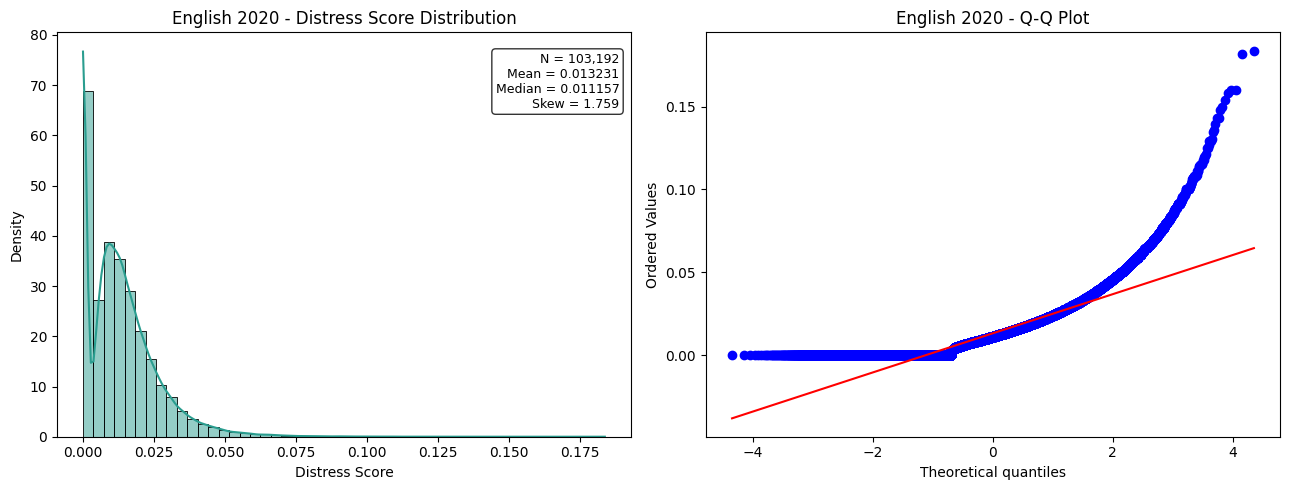

Saved plot to: distress_normality_english_2020.png


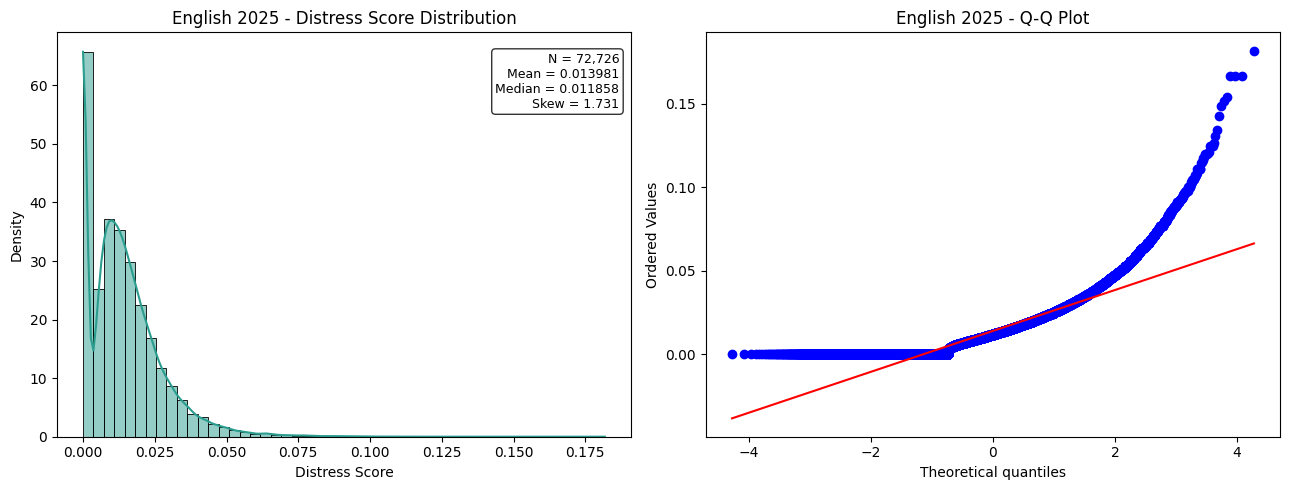

Saved plot to: distress_normality_english_2025.png


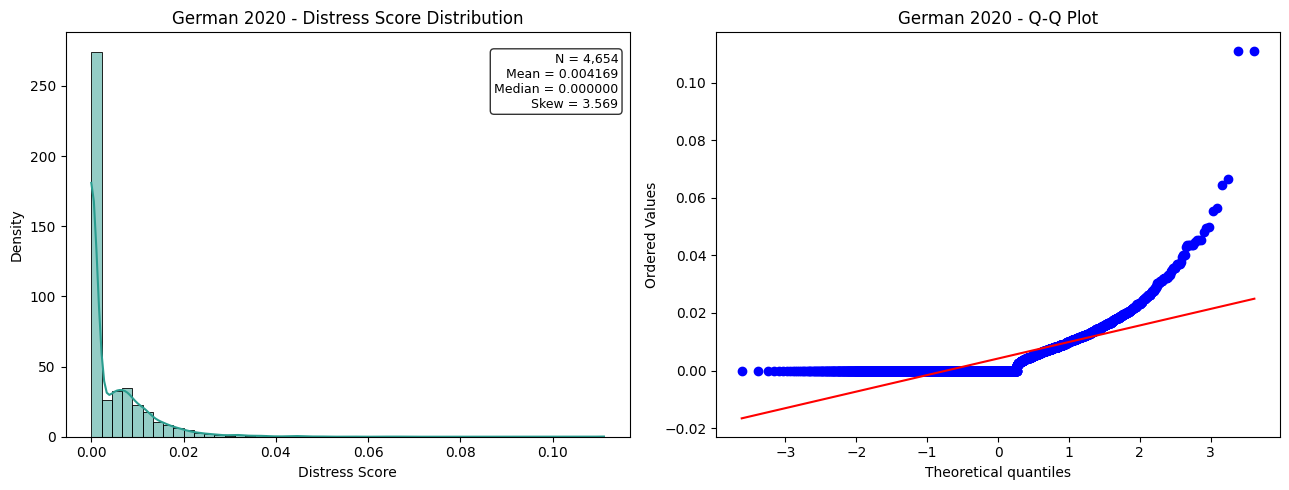

Saved plot to: distress_normality_german_2020.png


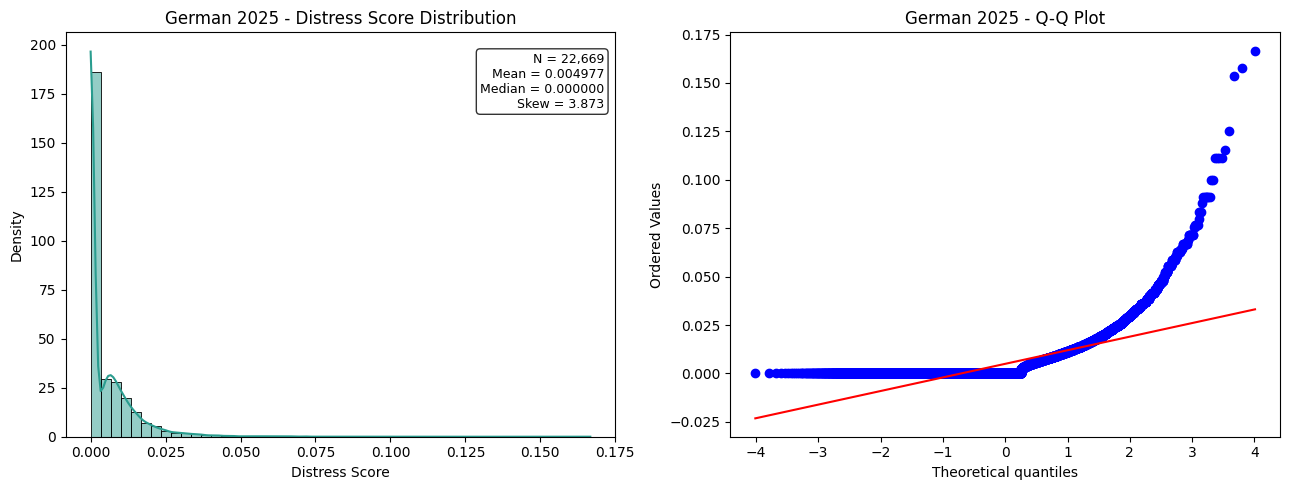

Saved plot to: distress_normality_german_2025.png


In [5]:
# Normality check for distress_score in each scored CSV
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

# If scored CSVs exist in ASSET_DIR, load them so this cell can be executed standalone
_scored_files = {
    'English 2020': os.path.join(ASSET_DIR, 'distress_english_2020_with_scores.csv'),
    'English 2025': os.path.join(ASSET_DIR, 'distress_english_2025_with_scores.csv'),
    'German 2020': os.path.join(ASSET_DIR, 'distress_german_2020_with_scores.csv'),
    'German 2025': os.path.join(ASSET_DIR, 'distress_german_2025_with_scores.csv'),
}

loaded_data = {}
for label, path in _scored_files.items():
    if os.path.exists(path):
        loaded_data[label] = pd.read_csv(path)
    else:
        print(f"Missing file: {Path(path).name}")

if len(loaded_data) != len(_scored_files):
    print("Not all scored CSVs are available. Run the scoring cell first, or place all four scored CSVs in ASSET_DIR.")


def plot_distress_normality(df, label):
    if 'distress_score' not in df.columns:
        print(f"Skipping {label}: distress_score not found.")
        return None

    scores = pd.to_numeric(df['distress_score'], errors='coerce').dropna()
    if scores.empty:
        print(f"Skipping {label}: no valid distress_score values.")
        return None

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    sns.histplot(scores, bins=50, kde=True, stat='density', color='#2A9D8F', ax=axes[0])
    axes[0].set_title(f'{label} - Distress Score Distribution')
    axes[0].set_xlabel('Distress Score')
    axes[0].set_ylabel('Density')

    stats.probplot(scores, dist='norm', plot=axes[1])
    axes[1].set_title(f'{label} - Q-Q Plot')

    mean_val = scores.mean()
    median_val = scores.median()
    skew_val = scores.skew()
    axes[0].text(
        0.98,
        0.95,
        f'N = {len(scores):,}\nMean = {mean_val:.6f}\nMedian = {median_val:.6f}\nSkew = {skew_val:.3f}',
        transform=axes[0].transAxes,
        ha='right',
        va='top',
        fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
    )

    plt.tight_layout()
    out_path = os.path.join(ASSET_DIR, f'distress_normality_{label.lower().replace(" ", "_")}.png')
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved plot to: {os.path.basename(out_path)}')
    return out_path


for label, df in loaded_data.items():
    plot_distress_normality(df, label)


In [7]:
# If scored CSVs exist in ASSET_DIR, load them so this cell can be executed standalone (starting from cell3)
_scored_en = {
    '2020': os.path.join(ASSET_DIR, 'distress_english_2020_with_scores.csv'),
    '2025': os.path.join(ASSET_DIR, 'distress_english_2025_with_scores.csv'),
}
_scored_de = {
    '2020': os.path.join(ASSET_DIR, 'distress_german_2020_with_scores.csv'),
    '2025': os.path.join(ASSET_DIR, 'distress_german_2025_with_scores.csv'),
}
if all(os.path.exists(p) for p in _scored_en.values()) and all(os.path.exists(p) for p in _scored_de.values()):
    en_data = {year: pd.read_csv(path) for year, path in _scored_en.items()}
    de_data = {year: pd.read_csv(path) for year, path in _scored_de.items()}
    print("Loaded scored CSVs into en_data and de_data from ASSET_DIR")
else:
    print("Scored CSVs not found — ensure cell1+cell2 ran before this cell, or place the four scored CSVs in ASSET_DIR.")

from scipy import stats
import seaborn as sns

# Statistical Tests (Mann-Whitney U + Cohen's d)

def cohens_d(group1, group2):
    """Calculate Cohen's d effect size"""
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(), group2.var()
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (group1.mean() - group2.mean()) / pooled_std

def interpret_cohens_d(d):
    """Interpret Cohen's d effect size"""
    abs_d = abs(d)
    if abs_d < 0.2:
        return "negligible"
    elif abs_d < 0.5:
        return "small"
    elif abs_d < 0.8:
        return "medium"
    else:
        return "large"

test_results = []
for lang_name, data_dict in [('English', en_data), ('German', de_data)]:
    scores_2020 = data_dict['2020']['distress_score'].dropna()
    scores_2025 = data_dict['2025']['distress_score'].dropna()
    
    # Mann-Whitney U test (non-parametric)
    u_stat, mw_p_value = stats.mannwhitneyu(scores_2020, scores_2025, alternative='two-sided')
    
    # Cohen's d
    cohens_d_val = cohens_d(scores_2020, scores_2025)
    effect_size_interpretation = interpret_cohens_d(cohens_d_val)
    
    # Rank-biserial correlation (effect size for Mann-Whitney U)
    n1, n2 = len(scores_2020), len(scores_2025)
    rank_biserial = 1 - (2 * u_stat) / (n1 * n2)
    
    test_results.append({
        'Language': lang_name,
        'MannWhitney_U': u_stat,
        'p_value': mw_p_value,
        'Significant': 'Yes' if mw_p_value < 0.05 else 'No',
        'Cohen_d': cohens_d_val,
        'Effect_Size': effect_size_interpretation,
        'Rank_Biserial': rank_biserial,
    })
    
    print(f"\n{lang_name}:")
    print(f"  Mann-Whitney U = {u_stat:.2f}, p-value = {mw_p_value:.4f} {'*' if mw_p_value < 0.05 else '(ns)'}")
    print(f"  Cohen's d = {cohens_d_val:.4f} ({effect_size_interpretation})")
    print(f"  Rank-biserial correlation = {rank_biserial:.4f}")
    if mw_p_value < 0.05:
        print(f"  → SIGNIFICANT difference between 2020 and 2025")
    else:
        print(f"  → NO significant difference between 2020 and 2025")

test_results_df = pd.DataFrame(test_results)
test_results_df.to_csv(os.path.join(ASSET_DIR, 'distress_statistical_tests.csv'), index=False)
print(f"\n✓ Saved test results to: distress_statistical_tests.csv")

Loaded scored CSVs into en_data and de_data from ASSET_DIR

English:
  Mann-Whitney U = 3626696666.50, p-value = 0.0000 *
  Cohen's d = -0.0581 (negligible)
  Rank-biserial correlation = 0.0335
  → SIGNIFICANT difference between 2020 and 2025

German:
  Mann-Whitney U = 51633803.00, p-value = 0.0100 *
  Cohen's d = -0.0917 (negligible)
  Rank-biserial correlation = 0.0212
  → SIGNIFICANT difference between 2020 and 2025

✓ Saved test results to: distress_statistical_tests.csv


In [3]:
# Statistical Tests (Mann-Whitney U + Cohen's d)

def cohens_d(group1, group2):
    """Calculate Cohen's d effect size"""
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(), group2.var()
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (group1.mean() - group2.mean()) / pooled_std

def interpret_cohens_d(d):
    """Interpret Cohen's d effect size"""
    abs_d = abs(d)
    if abs_d < 0.2:
        return "negligible"
    elif abs_d < 0.5:
        return "small"
    elif abs_d < 0.8:
        return "medium"
    else:
        return "large"

test_results = []
en_2020 = en_data['2020']['distress_score'].dropna()
de_2020 = de_data['2020']['distress_score'].dropna()

# Mann-Whitney U test (non-parametric)
u_stat, mw_p_value = stats.mannwhitneyu(en_2020, de_2020, alternative='two-sided')

# Cohen's d
cohens_d_val = cohens_d(en_2020, de_2020)
effect_size_interpretation = interpret_cohens_d(cohens_d_val)
    
# Rank-biserial correlation (effect size for Mann-Whitney U)
n1, n2 = len(en_2020), len(de_2020)
rank_biserial = 1 - (2 * u_stat) / (n1 * n2)

test_results.append({
		'MannWhitney_U': u_stat,
		'p_value': mw_p_value,
		'Significant': 'Yes' if mw_p_value < 0.05 else 'No',
		'Cohen_d': cohens_d_val,
		'Effect_Size': effect_size_interpretation,
		'Rank_Biserial': rank_biserial,
})

print(f"\n{lang_name}:")
print(f"  Mann-Whitney U = {u_stat:.2f}, p-value = {mw_p_value:.4f} {'*' if mw_p_value < 0.05 else '(ns)'}")
print(f"  Cohen's d = {cohens_d_val:.4f} ({effect_size_interpretation})")
print(f"  Rank-biserial correlation = {rank_biserial:.4f}")
if mw_p_value < 0.05:
		print(f"  → SIGNIFICANT difference between communities in 2020")
else:
		print(f"  → NO significant difference between communities in 2020")

test_results_df = pd.DataFrame(test_results)
test_results_df.to_csv(os.path.join(ASSET_DIR, 'distress_statistical_tests_communities.csv'), index=False)
print(f"\n✓ Saved test results to: distress_statistical_tests_communities.csv")


German:
  Mann-Whitney U = 359155122.50, p-value = 0.0000 *
  Cohen's d = 0.7232 (medium)
  Rank-biserial correlation = -0.4957
  → SIGNIFICANT difference between communities in 2020

✓ Saved test results to: distress_statistical_tests_communities.csv


/var/folders/qs/wnkjdcc560xf7634r7rj22zr0000gn/T/ipykernel_2607/996796425.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/qs/wnkjdcc560xf7634r7rj22zr0000gn/T/ipykernel_2607/996796425.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


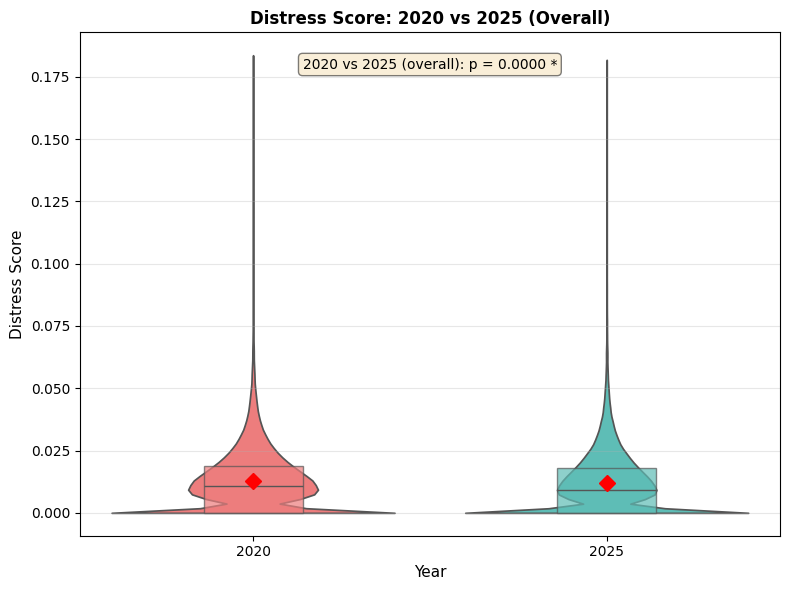

✓ Saved violin plot to: distress_violin_plot_2020_vs_2025_overall.png


In [12]:
# Visualization - Violin Plot

from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import os
import pandas as pd

# Combine English + German and compare only the overall 2020 vs 2025 distribution
plot_years_all = pd.DataFrame(
    [
        {'Year': year, 'Distress Score': score}
        for year in ['2020', '2025']
        for score in pd.concat([en_data[year]['distress_score'].dropna(), de_data[year]['distress_score'].dropna()])
    ]
)

scores_2020_all = pd.concat([
    en_data['2020']['distress_score'].dropna(),
    de_data['2020']['distress_score'].dropna(),
])
scores_2025_all = pd.concat([
    en_data['2025']['distress_score'].dropna(),
    de_data['2025']['distress_score'].dropna(),
])

u_stat_year, p_val_year = stats.mannwhitneyu(
    scores_2020_all,
    scores_2025_all,
    alternative='two-sided',
)
annotation_year = f"2020 vs 2025 (overall): p = {p_val_year:.4f} {'*' if p_val_year < 0.05 else '(ns)'}"

fig, ax = plt.subplots(figsize=(8, 6))
sns.violinplot(
    data=plot_years_all,
    x='Year',
    y='Distress Score',
    ax=ax,
    palette=['#FF6B6B', '#4ECDC4'],
    inner=None,
    cut=0,
)
sns.boxplot(
    data=plot_years_all,
    x='Year',
    y='Distress Score',
    ax=ax,
    width=0.28,
    palette=['#FF6B6B', '#4ECDC4'],
    showcaps=False,
    boxprops=dict(alpha=0.7),
    whiskerprops=dict(alpha=0),
    showfliers=False,
)

means_year = plot_years_all.groupby('Year')['Distress Score'].mean()
for i, (_, mean) in enumerate(means_year.items()):
    ax.plot(i, mean, marker='D', color='red', markersize=8, zorder=3)

ax.set_title('Distress Score: 2020 vs 2025 (Overall)', fontsize=12, fontweight='bold')
ax.set_ylabel('Distress Score', fontsize=11)
ax.set_xlabel('Year', fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.text(
    0.5,
    0.95,
    annotation_year,
    transform=ax.transAxes,
    ha='center',
    va='top',
    fontsize=10,
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
)

plt.tight_layout()
out_path = os.path.join(ASSET_DIR, 'distress_violin_plot_2020_vs_2025_overall.png')
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved violin plot to: {os.path.basename(out_path)}")

In [ ]:
# dominant_distress share comparison across en/de and 2020/2025
import numpy as np
import matplotlib.pyplot as plt

labels = ['en2020', 'en2025', 'de2020', 'de2025']
source_data = [
    en_data['2020'],
    en_data['2025'],
    de_data['2020'],
    de_data['2025'],
]

all_categories = []
for df in source_data:
    values = df['dominant_distress'].fillna('None').astype(str)
    for category in values.unique():
        if category not in all_categories:
            all_categories.append(category)

summary_rows = []
for label, df in zip(labels, source_data):
    counts = df['dominant_distress'].fillna('None').astype(str).value_counts(normalize=True)
    row = {'label': label}
    for category in all_categories:
        row[category] = float(counts.get(category, 0.0))
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('label')

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(summary_df.index))
bottom = np.zeros(len(summary_df.index))
colors = plt.cm.Set2(np.linspace(0, 1, len(all_categories)))

for category, color in zip(all_categories, colors):
    values = summary_df[category].values
    ax.bar(
        x,
        values,
        bottom=bottom,
        label=category,
        color=color,
        width=0.68,
        edgecolor='white',
        linewidth=0.8,
    )
    bottom += values

ax.set_xticks(x)
ax.set_xticklabels(summary_df.index)
ax.set_ylabel('Share of dominant_distress')
ax.set_ylim(0, 1)
ax.set_title('dominant_distress share across en2020, en2025, de2020, de2025')
ax.legend(title='dominant_distress', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()

out_path = os.path.join(ASSET_DIR, 'dominant_distress_share_en_de_2020_2025.png')
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved plot to: {out_path}')

In [ ]:
import json
import os
import pandas as pd
from collections import Counter

from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

# If scored CSVs exist in ASSET_DIR, load them so this cell can be executed standalone (starting from cell3)
_scored_en = {
    '2020': os.path.join(ASSET_DIR, 'distress_english_2020_with_scores.csv'),
    '2025': os.path.join(ASSET_DIR, 'distress_english_2025_with_scores.csv'),
}
_scored_de = {
    '2020': os.path.join(ASSET_DIR, 'distress_german_2020_with_scores.csv'),
    '2025': os.path.join(ASSET_DIR, 'distress_german_2025_with_scores.csv'),
}
if all(os.path.exists(p) for p in _scored_en.values()) and all(os.path.exists(p) for p in _scored_de.values()):
    en_data = {year: pd.read_csv(path) for year, path in _scored_en.items()}
    de_data = {year: pd.read_csv(path) for year, path in _scored_de.items()}
    print("Loaded scored CSVs into en_data and de_data from ASSET_DIR")
else:
    print("Scored CSVs not found — ensure cell1+cell2 ran before this cell, or place the four scored CSVs in ASSET_DIR.")


try:
    from sentence_transformers import SentenceTransformer
    from umap import UMAP
except ImportError as e:
    raise ImportError(
        "This cell requires sentence-transformers and umap-learn. "
        "Install with: pip install sentence-transformers umap-learn"
    ) from e

try:
    import torch
    from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline
    HAS_QWEN_RUNTIME = True
except Exception:
    HAS_QWEN_RUNTIME = False


print("HPC Configuration:")
print(f"  BATCH_SIZE_EMBEDDING: {BATCH_SIZE_EMBEDDING}")
print(f"  GPU_DEVICE: cuda:{GPU_DEVICE}")
print(f"  UMAP_N_JOBS: {UMAP_N_JOBS}")
print(f"  CUDA Available: {torch.cuda.is_available()}")

_embedding_model = None
_qwen_generator = None


def get_embedding_model():
    global _embedding_model
    if _embedding_model is None:
        _embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)
    return _embedding_model


def get_qwen_generator():
    global _qwen_generator
    if _qwen_generator is not None:
        return _qwen_generator
    if not HAS_QWEN_RUNTIME:
        return None

    try:
        hf_token = HUGGING_FACE_API_KEY
        torch_dtype = torch.float16 if torch.cuda.is_available() else torch.float32

        # Some Qwen model repos use custom code; enable trust_remote_code so transformers
        # can load vendor model classes. Use auth token if required.
        tokenizer = AutoTokenizer.from_pretrained(QWEN_MODEL_ID, token=hf_token)
        model = AutoModelForCausalLM.from_pretrained(
            QWEN_MODEL_ID,
            token=hf_token,
            trust_remote_code=True,
            torch_dtype=torch_dtype,
            low_cpu_mem_usage=True,
        )

        if torch.cuda.is_available():
            try:
                model = model.to(f"cuda:{GPU_DEVICE}")
                device = GPU_DEVICE
                print(f"Qwen model loaded on cuda:{GPU_DEVICE}")
            except Exception:
                # If explicit .to() fails (large models), fall back to letting pipeline/device_map handle it
                print("Failed to move model to specified CUDA device; pipeline will place it automatically")
                device = 0
        else:
            print("Qwen model loaded on CPU")
            device = -1

        _qwen_generator = pipeline(
            "text-generation",
            model=model,
            tokenizer=tokenizer,
            device=device,
        )
        return _qwen_generator
    except Exception as e:
        print(f"Failed to load Qwen: {e}")
        print("Ensure you have a recent `transformers` version (>=4.30) and a valid HUGGING_FACE_API_KEY.")
        return None


def build_topic_model(stop_words, min_topic_size):
    umap_for_topics = UMAP(
        n_neighbors=15,
        n_components=5,
        min_dist=0.0,
        metric="cosine",
        random_state=RANDOM_STATE,
        n_jobs=UMAP_N_JOBS,
    )

    vectorizer_model = CountVectorizer(
        stop_words=stop_words,
        max_df=0.95,
        ngram_range=(1, 2),
    )

    return BERTopic(
        umap_model=umap_for_topics,
        vectorizer_model=vectorizer_model,
        min_topic_size=min_topic_size,
        nr_topics="auto",
        calculate_probabilities=False,
        verbose=True,
    )


def prepare_topic_payload(topic_model, topic_info):
    payload = []
    for _, row in topic_info.iterrows():
        topic_id = int(row["Topic"])
        if topic_id == -1:
            continue
        words = topic_model.get_topic(topic_id) or []
        payload.append(
            {
                "topic_id": topic_id,
                "count": int(row["Count"]),
                "keywords": [w for w, _ in words[:8]],
            }
        )
    return payload


def build_qwen_prompt(topic_payload, min_topics=10, max_topics=15):
    return (
        "You are a topic analysis assistant. Merge similar BERTopic topics into broader themes.\n"
        f"Return between {min_topics} and {max_topics} merged topics if possible.\n"
        "Respond with JSON only in this exact schema:\n"
        "{\"merged_topics\":[{\"name\":\"...\",\"topic_ids\":[1,2,3]}]}\n"
        "Rules:\n"
        "- topic_ids must refer to the provided topic IDs\n"
        "- each topic ID should appear exactly once\n"
        "- names should be concise and meaningful\n\n"
        f"Input topic summaries:\n{json.dumps(topic_payload, ensure_ascii=False)}"
    )


def extract_json_dict(text):
    print(text)
    start = text.find("{")
    end = text.rfind("}")
    if start == -1 or end == -1 or end <= start:
        return None
    fragment = text[start : end + 1]
    try:
        return json.loads(fragment)
    except json.JSONDecodeError:
        return None



def fallback_merge_topics(topic_payload, min_topics=10, max_topics=15):
    if not topic_payload:
        return []

    ordered = sorted(topic_payload, key=lambda x: x["count"], reverse=True)
    topic_ids = [item["topic_id"] for item in ordered]

    target = min(max_topics, len(topic_ids))
    if len(topic_ids) >= min_topics:
        target = max(min_topics, target)

    chunks = [list(chunk) for chunk in np.array_split(topic_ids, target) if len(chunk) > 0]

    merged = []
    payload_by_id = {item["topic_id"]: item for item in ordered}
    for idx, chunk in enumerate(chunks, start=1):
        head = payload_by_id[int(chunk[0])]["keywords"]
        short_name = ", ".join(head[:3]) if head else f"Merged Topic {idx}"
        merged.append(
            {
                "name": f"{idx}. {short_name}",
                "topic_ids": [int(x) for x in chunk],
            }
        )
    return merged



def normalize_merged_topics(raw_output, topic_payload):
    valid_topic_ids = {int(item["topic_id"]) for item in topic_payload}

    candidates = raw_output.get("merged_topics", []) if isinstance(raw_output, dict) else []
    normalized = []
    used_ids = set()

    for group in candidates:
        if not isinstance(group, dict):
            continue
        name = str(group.get("name", "")).strip()
        ids = group.get("topic_ids", [])
        if not isinstance(ids, list):
            continue

        clean_ids = []
        for topic_id in ids:
            try:
                tid = int(topic_id)
            except (TypeError, ValueError):
                continue
            if tid in valid_topic_ids and tid not in used_ids:
                clean_ids.append(tid)
                used_ids.add(tid)

        if clean_ids:
            normalized.append(
                {
                    "name": name if name else f"Merged Topic {len(normalized) + 1}",
                    "topic_ids": clean_ids,
                }
            )

    remaining = sorted(valid_topic_ids - used_ids)
    for topic_id in remaining:
        normalized.append(
            {
                "name": f"Topic {topic_id}",
                "topic_ids": [topic_id],
            }
        )

    return normalized



def merge_topics_with_qwen(topic_payload, min_topics=10, max_topics=15):
    if not topic_payload:
        return []

    generator = get_qwen_generator()
    if generator is None:
        print("Qwen runtime not available. Using deterministic fallback merging.")
        return fallback_merge_topics(topic_payload, min_topics=min_topics, max_topics=max_topics)

    prompt = build_qwen_prompt(topic_payload, min_topics=min_topics, max_topics=max_topics)

    outputs = generator(
        prompt,
        max_new_tokens=1000,
        do_sample=False,
        temperature=0.0,
        return_full_text=False,
    )
    generated_text = outputs[0].get("generated_text", "")
    parsed = extract_json_dict(generated_text)

    if parsed is None:
        print("Qwen output was not valid JSON. Using deterministic fallback merging.")
        return fallback_merge_topics(topic_payload, min_topics=min_topics, max_topics=max_topics)

    merged = normalize_merged_topics(parsed, topic_payload)
    return merged if merged else fallback_merge_topics(topic_payload, min_topics=min_topics, max_topics=max_topics)



def apply_merged_topics(topic_df, merged_groups):
    topic_to_name = {}
    for group in merged_groups:
        for topic_id in group["topic_ids"]:
            topic_to_name[int(topic_id)] = group["name"]

    topic_df = topic_df.copy()
    topic_df["merged_topic"] = topic_df["topic"].map(topic_to_name)
    topic_df.loc[topic_df["topic"] == -1, "merged_topic"] = "Outlier"
    topic_df["merged_topic"] = topic_df["merged_topic"].fillna(topic_df["topic"].map(lambda x: f"Topic {x}"))
    return topic_df, topic_to_name



def make_2d_topic_plot(topic_df, embeddings, language_name, year):
    plot_df = topic_df.copy()
    if plot_df.empty or len(plot_df) != len(embeddings):
        print(f"No valid data to plot for {language_name} {year}; skipping 2D plot.")
        return None

    # HPC: use all rows for projection
    plot_df = plot_df.reset_index(drop=True)
    plot_embeddings = embeddings

    print(f"Creating 2D UMAP projection for {len(plot_df)} documents ({language_name} {year})...")
    umap_2d = UMAP(
        n_components=2,
        metric="cosine",
        random_state=RANDOM_STATE,
        min_dist=0.0,
        n_neighbors=50,
        n_jobs=UMAP_N_JOBS,
    )
    coords_2d = umap_2d.fit_transform(plot_embeddings)
    plot_df["x"] = coords_2d[:, 0]
    plot_df["y"] = coords_2d[:, 1]

    topic_counts = Counter(plot_df["merged_topic"])
    top_groups = [name for name, _ in topic_counts.most_common(TARGET_TOPIC_MAX)]
    if "Outlier" in topic_counts and "Outlier" not in top_groups:
        top_groups.append("Outlier")

    def normalize_group(name):
        return name if name in top_groups else "Other"

    plot_df["plot_group"] = plot_df["merged_topic"].apply(normalize_group)

    import seaborn as sns
    fig, ax = plt.subplots(figsize=(12, 8))
    # Exclude 'Outlier' from the 2D scatter to reduce visual noise
    plot_df_plot = plot_df[plot_df["plot_group"] != "Outlier"].copy()
    unique_groups = sorted(plot_df_plot["plot_group"].unique().tolist())
    # Use a brighter, more vivid palette
    palette = sns.color_palette("bright", n_colors=max(3, len(unique_groups)))
    colors = {group: palette[i % len(palette)] for i, group in enumerate(unique_groups)}
    # Keep 'Other' as a neutral color if present
    if "Other" in colors:
        colors["Other"] = (0.62, 0.62, 0.62)

    for group in unique_groups:
        subset = plot_df_plot[plot_df_plot["plot_group"] == group]
        ax.scatter(
            subset["x"],
            subset["y"],
            s=20,
            alpha=0.85,
            label=f"{group} (n={len(subset)})",
            color=colors[group],
            edgecolors="none",
        )

    ax.set_title(f"{language_name} {year} UMAP 2D Projection (Merged Topics)", fontsize=13, fontweight="bold")
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    ax.grid(alpha=0.2)
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8, frameon=False)
    plt.tight_layout()

    plot_path = os.path.join(ASSET_DIR, f"distress_{language_name.lower()}_{year}_bertopic_merged_umap2d.png")
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved merged-topic UMAP 2D plot to: {os.path.basename(plot_path)}")
    return plot_path



def run_bertopic_by_year(language_name, data_dict, stop_words):
    year_results = {}
    embedding_model = get_embedding_model()

    for year, df in data_dict.items():
        if "distress_score" not in df.columns:
            print(f"Skipping {language_name} {year}: distress_score not found.")
            continue

        positive_df = df[df["distress_score"] > 0].copy()
        positive_df["text_for_keywords"] = positive_df["text_for_keywords"].fillna("").astype(str)
        positive_df = positive_df[positive_df["text_for_keywords"].str.strip() != ""].copy()

        if positive_df.empty:
            print(f"No rows with distress_score > 0 for {language_name} {year}; skipping BERTopic.")
            continue

        model_df = positive_df.copy()
        				# sample for local test        
        model_df = model_df.sample(n=100, random_state=RANDOM_STATE)

        docs = model_df["text_for_keywords"].tolist()
        min_topic_size = max(2, min(10, len(docs) // 10 if len(docs) >= 10 else 2))

        print(f"\n{'=' * 70}")
        print(f"{language_name} {year} BERTopic (Full Data - HPC Optimized)")
        print(f"{'=' * 70}")
        print(f"  Total documents: {len(docs)}")
        print(f"  Min topic size: {min_topic_size}")
        print(f"  Distress score range: {model_df['distress_score'].min():.6f} - {model_df['distress_score'].max():.6f}")

        print(f"Generating embeddings with batch_size={BATCH_SIZE_EMBEDDING}...")
        embeddings = embedding_model.encode(
            docs,
            show_progress_bar=EMBEDDING_SHOW_PROGRESS,
            batch_size=BATCH_SIZE_EMBEDDING,
        )
        embeddings = np.asarray(embeddings)

        topic_model = build_topic_model(stop_words, min_topic_size)
        topics, _ = topic_model.fit_transform(docs, embeddings)
        model_df["topic"] = topics

        topic_info = topic_model.get_topic_info()
        topic_payload = prepare_topic_payload(topic_model, topic_info)
        print(f"Initial topics before merging: {len(topic_payload)}")

        merged_groups = merge_topics_with_qwen(
            topic_payload,
            min_topics=TARGET_TOPIC_MIN,
            max_topics=TARGET_TOPIC_MAX,
        )
        print(f"Merged topics: {len(merged_groups)}")

        model_df, topic_to_name = apply_merged_topics(model_df, merged_groups)

        merged_map_rows = []
        for group in merged_groups:
            for topic_id in group["topic_ids"]:
                merged_map_rows.append(
                    {
                        "topic_id": int(topic_id),
                        "merged_topic": group["name"],
                    }
                )
        merged_map_df = pd.DataFrame(merged_map_rows).sort_values(["merged_topic", "topic_id"]).reset_index(drop=True)

        topic_info_path = os.path.join(ASSET_DIR, f"distress_{language_name.lower()}_{year}_bertopic_topic_info.csv")
        assignments_path = os.path.join(ASSET_DIR, f"distress_{language_name.lower()}_{year}_positive_scores_bertopic_assignments.csv")
        merged_map_path = os.path.join(ASSET_DIR, f"distress_{language_name.lower()}_{year}_bertopic_merged_topic_map.csv")

        model_df.to_csv(assignments_path, index=False)
        topic_info.to_csv(topic_info_path, index=False)
        merged_map_df.to_csv(merged_map_path, index=False)

        print(f"Saved topic assignments to: {os.path.basename(assignments_path)}")
        print(f"Saved topic info to: {os.path.basename(topic_info_path)}")
        print(f"Saved merged topic map to: {os.path.basename(merged_map_path)}")

        print("Top merged topics:")
        print(model_df["merged_topic"].value_counts().head(15).to_string())

        plot_path = make_2d_topic_plot(model_df, embeddings, language_name, year)

        year_results[year] = {
            "topic_model": topic_model,
            "topic_df": model_df,
            "topic_info": topic_info,
            "topic_info_path": topic_info_path,
            "assignments_path": assignments_path,
            "merged_map_path": merged_map_path,
            "topic_to_name": topic_to_name,
            "plot_path": plot_path,
        }

    return year_results


print("Starting BERTopic analysis with full data (HPC GPU optimized)...")
english_topic_results = run_bertopic_by_year(
    "English",
    en_data,
    stop_words=list(ENGLISH_STOP_WORDS),
)

german_topic_results = run_bertopic_by_year(
    "German",
    de_data,
    stop_words=list(GERMAN_STOP_WORDS),
)

print("\n" + "=" * 70)
print("BERTopic analysis completed!")
print("=" * 70)


: 